In [1]:
import sys
sys.path.append("../../")

Training with seed=100
Epoch     0 | Loss: 147653574656.000000 | Data: 14725025792.000000 | ODE: 813284.000000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  1000 | Loss: 8547468288.000000 | Data: 615426176.000000 | ODE: 19824150.000000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  2000 | Loss: 1647459840.000000 | Data: 76360704.000000 | ODE: 12465308.000000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  3000 | Loss: 119190560.000000 | Data: 8554502.000000 | ODE: 4041475.250000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  4000 | Loss: 62173484.000000 | Data: 5702841.500000 | ODE: 3484322.500000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  5000 | Loss: 52585500.000000 | Data: 4892839.500000 | ODE: 3433389.250000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  6000 | Loss: 46682564.000000 | Data: 4301490.000000 | ODE: 3541023.250000
Params: β=0.0458, γ=0.0371, μ=0.0023
---
Epoch  7000 | Loss: 58964380.000000 | Data: 5536898.500000 | ODE: 3550840.500000
Params: β=0.0458, γ=0.037

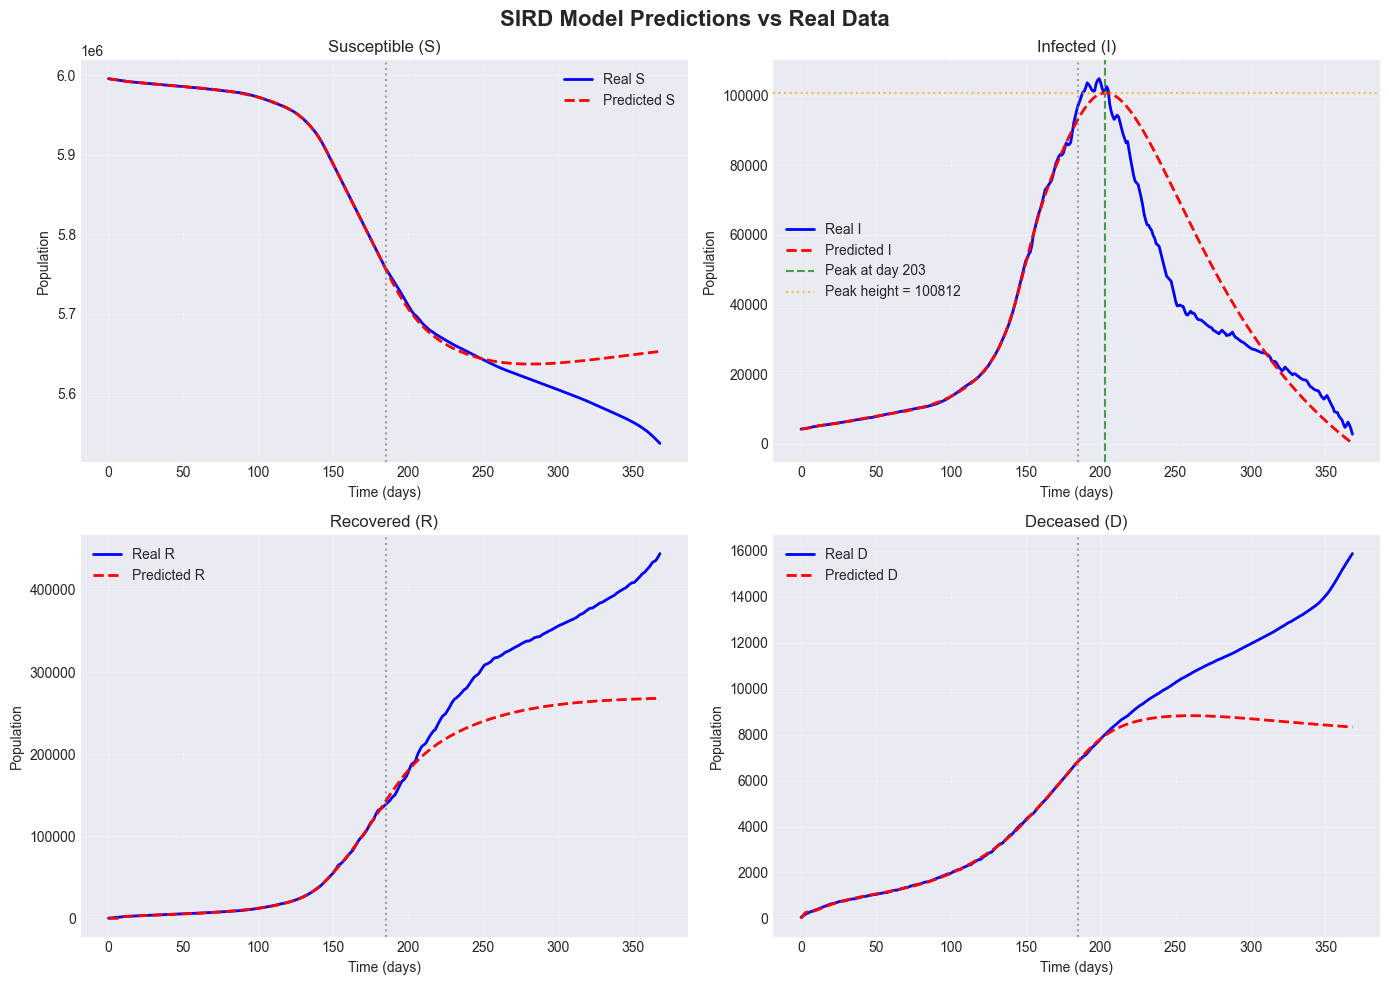

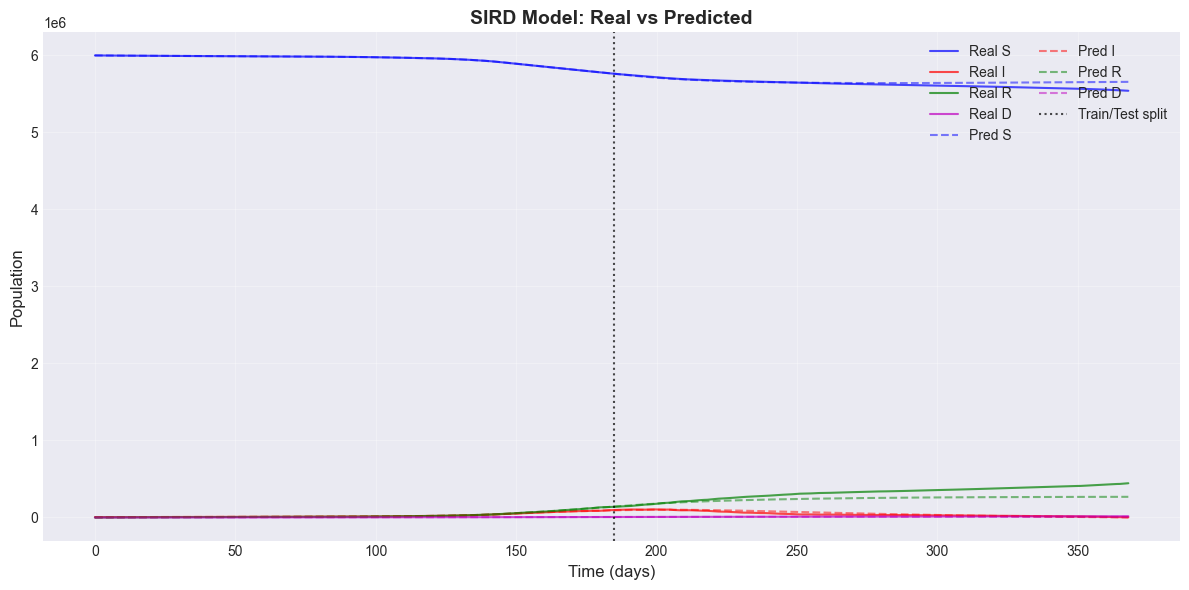


FINAL MODEL PARAMETERS
β (infection rate)  = 0.045800
γ (recovery rate)   = 0.037100
μ (mortality rate)  = 0.002290
R₀ = β/γ             = 1.2345


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from agents.PINN_const import EINN_PINN

# ============================================
# Seed
# ============================================

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================
# Данные
# ============================================

covid_cases = pd.read_csv('./real_datasets/covid-19_Kouprianov.csv')

S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values

timesteps = np.arange(len(S)).astype(float)

train_size = 185
population = S[0] + I[0] + R[0] + D[0]

# ============================================
# Параметры
# ============================================

new_params = {
    "beta": 0.0458,
    "gamma": 0.0371,
    "mu": 0.00229
}

# ============================================
# Обучение модели (один раз)
# ============================================

seed = 100
print(f"Training with seed={seed}")
set_seed(seed)

model = EINN_PINN(
    t=timesteps,
    S_data=S,
    I_data=I,
    R_data=R,
    D_data=D,
    population=population,
    train_size=train_size,
    init_params=new_params,
    device='cuda'
)

model.train_model(
    n_epoch=10_000,
    lambda_data=10.0,
    lambda_ode=1.0,
    lambda_ic=0.1,
    lambda_bc=0.1
)

# Предсказания
S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)

# Конвертируем в numpy
S_pred = S_pred.numpy()
I_pred = I_pred.numpy()
R_pred = R_pred.numpy()
D_pred = D_pred.numpy()

# Пик инфекции
peak_pos = np.argmax(I_pred)
peak_height = np.max(I_pred)

params = model.params.get_params_dict()

print(f"\nResults:")
print(f"Peak position = {peak_pos}")
print(f"Peak height = {peak_height:.2f}")
print(f"beta = {params['beta']:.5f}, gamma = {params['gamma']:.5f}, mu = {params['mu']:.5f}")

# ============================================
# Графики
# ============================================

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SIRD Model Predictions vs Real Data', fontsize=16, fontweight='bold')

# Susceptible
axes[0, 0].plot(timesteps, S, 'b-', label='Real S', linewidth=2)
axes[0, 0].plot(timesteps, S_pred, 'r--', label='Predicted S', linewidth=2)
axes[0, 0].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].set_title('Susceptible (S)', fontsize=12)
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Population')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Infected
axes[0, 1].plot(timesteps, I, 'b-', label='Real I', linewidth=2)
axes[0, 1].plot(timesteps, I_pred, 'r--', label='Predicted I', linewidth=2)
axes[0, 1].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[0, 1].axvline(x=peak_pos, color='green', linestyle='--', alpha=0.7, label=f'Peak at day {peak_pos}')
axes[0, 1].axhline(y=peak_height, color='orange', linestyle=':', alpha=0.7, label=f'Peak height = {peak_height:.0f}')
axes[0, 1].set_title('Infected (I)', fontsize=12)
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Population')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Recovered
axes[1, 0].plot(timesteps, R, 'b-', label='Real R', linewidth=2)
axes[1, 0].plot(timesteps, R_pred, 'r--', label='Predicted R', linewidth=2)
axes[1, 0].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[1, 0].set_title('Recovered (R)', fontsize=12)
axes[1, 0].set_xlabel('Time (days)')
axes[1, 0].set_ylabel('Population')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Deceased
axes[1, 1].plot(timesteps, D, 'b-', label='Real D', linewidth=2)
axes[1, 1].plot(timesteps, D_pred, 'r--', label='Predicted D', linewidth=2)
axes[1, 1].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].set_title('Deceased (D)', fontsize=12)
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Population')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./experiment_results/predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Дополнительный график: сравнение всех на одном
# ============================================

fig2, ax = plt.subplots(figsize=(12, 6))

ax.plot(timesteps, S, 'b-', label='Real S', alpha=0.7)
ax.plot(timesteps, I, 'r-', label='Real I', alpha=0.7)
ax.plot(timesteps, R, 'g-', label='Real R', alpha=0.7)
ax.plot(timesteps, D, 'm-', label='Real D', alpha=0.7)

ax.plot(timesteps, S_pred, 'b--', label='Pred S', alpha=0.5)
ax.plot(timesteps, I_pred, 'r--', label='Pred I', alpha=0.5)
ax.plot(timesteps, R_pred, 'g--', label='Pred R', alpha=0.5)
ax.plot(timesteps, D_pred, 'm--', label='Pred D', alpha=0.5)

ax.axvline(x=train_size, color='black', linestyle=':', alpha=0.7, label='Train/Test split')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title('SIRD Model: Real vs Predicted', fontsize=14, fontweight='bold')
ax.legend(ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./experiment_results/predictions_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Вывод параметров на экран
# ============================================

print("\n" + "="*60)
print("FINAL MODEL PARAMETERS")
print("="*60)
print(f"β (infection rate)  = {params['beta']:.6f}")
print(f"γ (recovery rate)   = {params['gamma']:.6f}")
print(f"μ (mortality rate)  = {params['mu']:.6f}")
print(f"R₀ = β/γ             = {params['beta']/params['gamma']:.4f}")
print("="*60)

Epoch     0 | Loss: 6548731.000000 | Data: 3723914.000000 | ODE: 2818488.250000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  1000 | Loss: 6420135.000000 | Data: 3658081.500000 | ODE: 2755726.250000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  2000 | Loss: 6202255.000000 | Data: 3499566.000000 | ODE: 2696361.750000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  3000 | Loss: 5972793.000000 | Data: 3321907.500000 | ODE: 2644558.750000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  4000 | Loss: 5733496.000000 | Data: 3130466.500000 | ODE: 2596702.750000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  5000 | Loss: 5486927.500000 | Data: 2924412.250000 | ODE: 2556187.250000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  6000 | Loss: 5227620.500000 | Data: 2703330.250000 | ODE: 2517963.250000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  7000 | Loss: 4967508.000000 | Data: 2477806.000000 | ODE: 2483375.250000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  8000 | Loss: 11956319.000

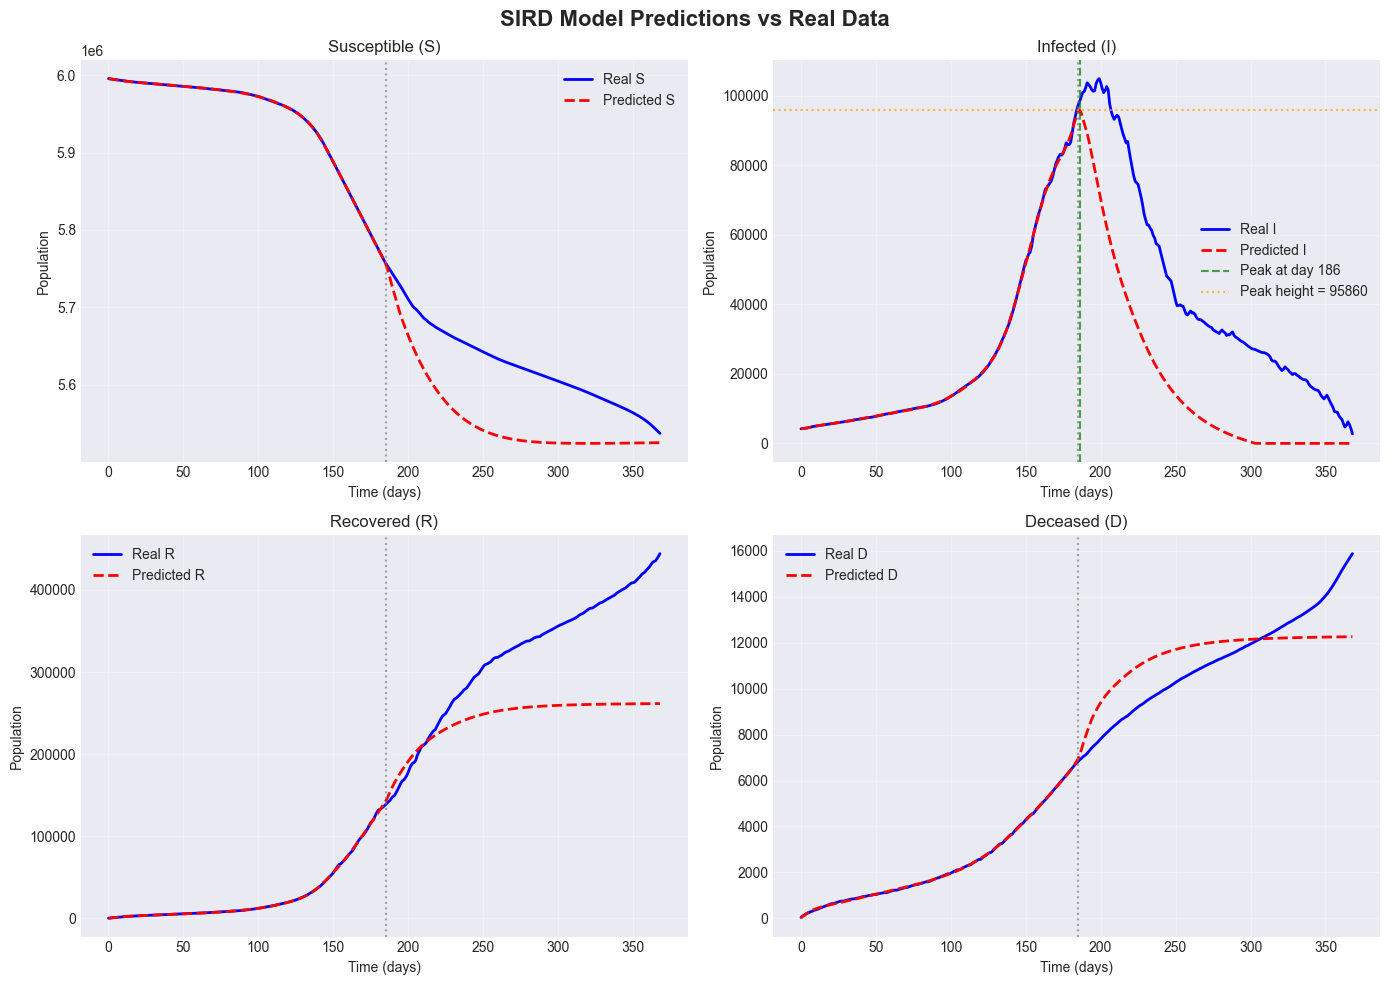

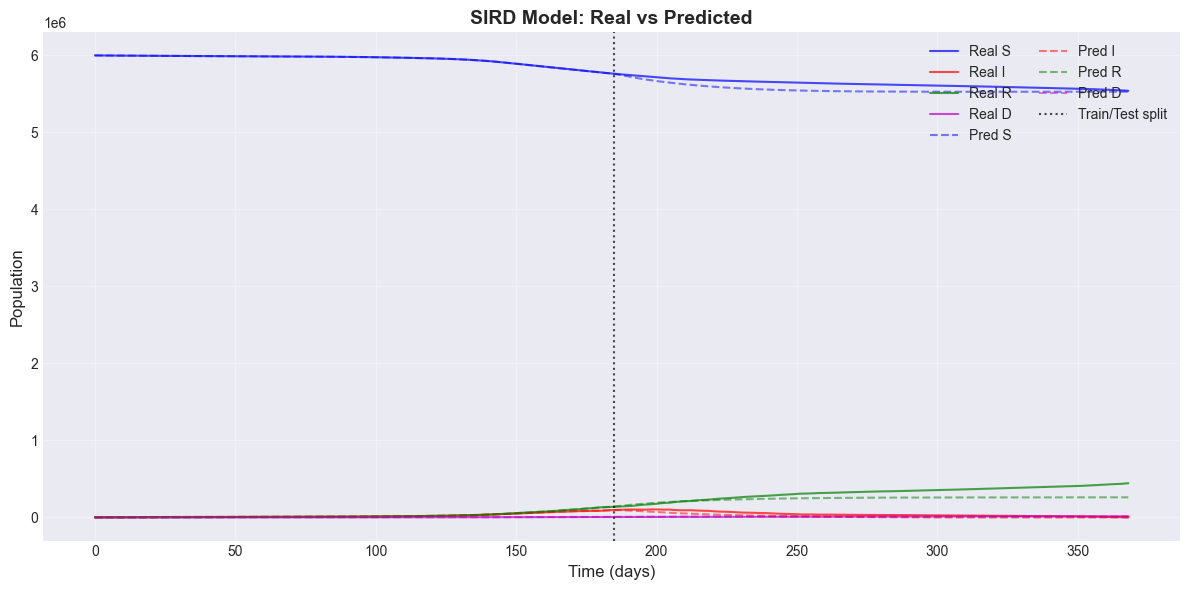


FINAL MODEL PARAMETERS
β (infection rate)  = 0.072400
γ (recovery rate)   = 0.032500
μ (mortality rate)  = 0.001950
R₀ = β/γ             = 2.2277


In [3]:

model.train_model(
    n_epoch=10_000,
    lambda_data=1.0,
    lambda_ode=1.0,
    lambda_ic=0.1,
    lambda_bc=0.1
)

# Предсказания
S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)

# Конвертируем в numpy
S_pred = S_pred.numpy()
I_pred = I_pred.numpy()
R_pred = R_pred.numpy()
D_pred = D_pred.numpy()

# Пик инфекции
peak_pos = np.argmax(I_pred)
peak_height = np.max(I_pred)

params = model.params.get_params_dict()

print(f"\nResults:")
print(f"Peak position = {peak_pos}")
print(f"Peak height = {peak_height:.2f}")
print(f"beta = {params['beta']:.5f}, gamma = {params['gamma']:.5f}, mu = {params['mu']:.5f}")

# ============================================
# Графики
# ============================================

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SIRD Model Predictions vs Real Data', fontsize=16, fontweight='bold')

# Susceptible
axes[0, 0].plot(timesteps, S, 'b-', label='Real S', linewidth=2)
axes[0, 0].plot(timesteps, S_pred, 'r--', label='Predicted S', linewidth=2)
axes[0, 0].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].set_title('Susceptible (S)', fontsize=12)
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Population')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Infected
axes[0, 1].plot(timesteps, I, 'b-', label='Real I', linewidth=2)
axes[0, 1].plot(timesteps, I_pred, 'r--', label='Predicted I', linewidth=2)
axes[0, 1].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[0, 1].axvline(x=peak_pos, color='green', linestyle='--', alpha=0.7, label=f'Peak at day {peak_pos}')
axes[0, 1].axhline(y=peak_height, color='orange', linestyle=':', alpha=0.7, label=f'Peak height = {peak_height:.0f}')
axes[0, 1].set_title('Infected (I)', fontsize=12)
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Population')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Recovered
axes[1, 0].plot(timesteps, R, 'b-', label='Real R', linewidth=2)
axes[1, 0].plot(timesteps, R_pred, 'r--', label='Predicted R', linewidth=2)
axes[1, 0].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[1, 0].set_title('Recovered (R)', fontsize=12)
axes[1, 0].set_xlabel('Time (days)')
axes[1, 0].set_ylabel('Population')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Deceased
axes[1, 1].plot(timesteps, D, 'b-', label='Real D', linewidth=2)
axes[1, 1].plot(timesteps, D_pred, 'r--', label='Predicted D', linewidth=2)
axes[1, 1].axvline(x=train_size, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].set_title('Deceased (D)', fontsize=12)
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Population')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./experiment_results/predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Дополнительный график: сравнение всех на одном
# ============================================

fig2, ax = plt.subplots(figsize=(12, 6))

ax.plot(timesteps, S, 'b-', label='Real S', alpha=0.7)
ax.plot(timesteps, I, 'r-', label='Real I', alpha=0.7)
ax.plot(timesteps, R, 'g-', label='Real R', alpha=0.7)
ax.plot(timesteps, D, 'm-', label='Real D', alpha=0.7)

ax.plot(timesteps, S_pred, 'b--', label='Pred S', alpha=0.5)
ax.plot(timesteps, I_pred, 'r--', label='Pred I', alpha=0.5)
ax.plot(timesteps, R_pred, 'g--', label='Pred R', alpha=0.5)
ax.plot(timesteps, D_pred, 'm--', label='Pred D', alpha=0.5)

ax.axvline(x=train_size, color='black', linestyle=':', alpha=0.7, label='Train/Test split')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title('SIRD Model: Real vs Predicted', fontsize=14, fontweight='bold')
ax.legend(ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./experiment_results/predictions_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Вывод параметров на экран
# ============================================

print("\n" + "="*60)
print("FINAL MODEL PARAMETERS")
print("="*60)
print(f"β (infection rate)  = {params['beta']:.6f}")
print(f"γ (recovery rate)   = {params['gamma']:.6f}")
print(f"μ (mortality rate)  = {params['mu']:.6f}")
print(f"R₀ = β/γ             = {params['beta']/params['gamma']:.4f}")
print("="*60)

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from scipy import stats

from NEW_PINN_LLM_SUR.LLM_epiparam_generator.agents.PINN_const import EINN_PINN

# ============================================
# Конфигурация
# ============================================

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================
# Загрузка данных
# ============================================

covid_cases = pd.read_csv('../real_datasets/covid-19_Kouprianov.csv')

S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values

timesteps = np.arange(len(S)).astype(float)

train_size = 185
population = S[0] + I[0] + R[0] + D[0]

# Базовые параметры
new_params = {
    "beta": 0.0724,
    "gamma": 0.0325,
    "mu": 0.00195
}

# ============================================
# Эксперимент 1: Sweep по λ
# ============================================

lambda_configs = [
    {"name": "balanced", "lambda_data": 1.0, "lambda_ode": 1.0},
    {"name": "pure_sird", "lambda_data": 0.0, "lambda_ode": 1.0},
    {"name": "data_dominant", "lambda_data": 10.0, "lambda_ode": 0.1},
    {"name": "physics_dominant", "lambda_data": 0.1, "lambda_ode": 1.0},
]

# Будем тестировать с разными beta
beta_factors = [0.5, 1.0, 2.0]

n_runs = 5  # Количество запусков для каждой конфигурации
n_epochs = 10000

output_dir = "./lambda_sweep_results"
os.makedirs(output_dir, exist_ok=True)

# ============================================
# Эксперимент 2: Логирование лоссов по эпохам
# ============================================

class LossLogger:
    def __init__(self):
        self.data_losses = []
        self.ode_losses = []
        self.total_losses = []
        self.epochs = []
    
    def log(self, epoch, data_loss, ode_loss, total_loss):
        self.epochs.append(epoch)
        self.data_losses.append(data_loss)
        self.ode_losses.append(ode_loss)
        self.total_losses.append(total_loss)
    
    def plot(self, save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].plot(self.epochs, self.data_losses, label='Data Loss', linewidth=2)
        axes[0].plot(self.epochs, self.ode_losses, label='ODE Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_yscale('log')
        axes[0].set_title('Loss Components')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(self.epochs, self.total_losses, label='Total Loss', linewidth=2, color='purple')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_yscale('log')
        axes[1].set_title('Total Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        
    def save(self, path):
        df = pd.DataFrame({
            'epoch': self.epochs,
            'data_loss': self.data_losses,
            'ode_loss': self.ode_losses,
            'total_loss': self.total_losses
        })
        df.to_csv(path, index=False)

# ============================================
# Функция для одного эксперимента
# ============================================

def run_experiment(lambda_data, lambda_ode, beta_factor, config_name, run_id, seed):
    """Запуск одного эксперимента с заданными весами"""
    
    print(f"\n{'='*60}")
    print(f"Experiment: {config_name} | beta_factor={beta_factor} | run={run_id+1}/{n_runs}")
    print(f"λ_data={lambda_data}, λ_ode={lambda_ode}, seed={seed}")
    print(f"{'='*60}")
    
    # Модифицируем beta
    params = new_params.copy()
    params["beta"] = params["beta"] * beta_factor
    
    set_seed(seed)
    
    # Создаем модель
    model = EINN_PINN(
        t=timesteps,
        S_data=S,
        I_data=I,
        R_data=R,
        D_data=D,
        population=population,
        train_size=train_size,
        init_params=params,
        device='cuda'
    )
    
    # Обучаем с заданными весами
    model.train_model(
        n_epoch=n_epochs,
        lambda_data=lambda_data,
        lambda_ode=lambda_ode,
        lambda_ic=0.1,
        lambda_bc=0.1
    )
    
    # Получаем предсказания
    S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)
    I_pred = I_pred.numpy()
    
    # Анализируем пик
    peak_pos = np.argmax(I_pred)
    peak_height = np.max(I_pred)
    
    # Финальные параметры
    final_params = model.params.get_params_dict()
    
    # Сохраняем результаты
    result = {
        "config": config_name,
        "beta_factor": beta_factor,
        "lambda_data": lambda_data,
        "lambda_ode": lambda_ode,
        "run_id": run_id,
        "seed": seed,
        "peak_position": peak_pos,
        "peak_height": peak_height,
        "beta_initial": params["beta"],
        "beta_final": final_params["beta"],
        "gamma_final": final_params["gamma"],
        "mu_final": final_params["mu"],
    }
    
    print(f"Peak: pos={peak_pos}, height={peak_height:.2f}")
    print(f"β: {params['beta']:.5f} → {final_params['beta']:.5f}")
    
    return result, model

# ============================================
# Функция для визуализации результатов sweep
# ============================================

def visualize_sweep_results(results_df):
    """Визуализация результатов sweep по λ"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Effect of Loss Weights on Peak Behavior', fontsize=14, fontweight='bold')
    
    # 1. Peak height vs beta factor (with error bars)
    ax1 = axes[0, 0]
    for config in results_df['config'].unique():
        subset = results_df[results_df['config'] == config]
        means = subset.groupby('beta_factor')['peak_height'].mean()
        stds = subset.groupby('beta_factor')['peak_height'].std()
        ax1.errorbar(means.index, means.values, yerr=stds.values, 
                    marker='o', label=config, linewidth=2, markersize=8, capsize=5)
    ax1.set_xlabel('β multiplier')
    ax1.set_ylabel('Peak Height')
    ax1.set_title('Peak Height vs β (with std deviation)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Peak position vs beta factor
    ax2 = axes[0, 1]
    for config in results_df['config'].unique():
        subset = results_df[results_df['config'] == config]
        means = subset.groupby('beta_factor')['peak_position'].mean()
        stds = subset.groupby('beta_factor')['peak_position'].std()
        ax2.errorbar(means.index, means.values, yerr=stds.values,
                    marker='s', label=config, linewidth=2, markersize=8, capsize=5)
    ax2.set_xlabel('β multiplier')
    ax2.set_ylabel('Peak Position (day)')
    ax2.set_title('Peak Timing vs β')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Parameter change (β_final / β_initial)
    ax3 = axes[1, 0]
    for config in results_df['config'].unique():
        subset = results_df[results_df['config'] == config]
        beta_ratio = subset['beta_final'] / subset['beta_initial']
        means = beta_ratio.groupby(subset['beta_factor']).mean()
        stds = beta_ratio.groupby(subset['beta_factor']).std()
        ax3.errorbar(means.index, means.values, yerr=stds.values,
                    marker='D', label=config, linewidth=2, markersize=8, capsize=5)
    ax3.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    ax3.set_xlabel('β multiplier')
    ax3.set_ylabel('β_final / β_initial')
    ax3.set_title('Parameter Adaptation')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Boxplot of peak heights for β=2.0
    ax4 = axes[1, 1]
    beta2_data = results_df[results_df['beta_factor'] == 2.0]
    data_for_box = [beta2_data[beta2_data['config'] == c]['peak_height'].values 
                    for c in results_df['config'].unique()]
    ax4.boxplot(data_for_box, labels=results_df['config'].unique())
    ax4.set_xlabel('Configuration')
    ax4.set_ylabel('Peak Height (β=2.0)')
    ax4.set_title('Distribution of Peak Heights (β×2)')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "lambda_sweep_summary.png"), dpi=150, bbox_inches='tight')
    plt.close()

# ============================================
# Функция для сравнения предсказаний (один representative run)
# ============================================

def plot_predictions_comparison(results_df, timesteps, I_real):
    """Сравнение предсказаний для разных конфигураций (берем последний run)"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Model Predictions for Different λ Configurations (β×2)', fontsize=14, fontweight='bold')
    
    colors = ['blue', 'red', 'green', 'purple']
    
    for idx, config in enumerate(lambda_configs):
        # Берем последний run для β=2.0
        subset = results_df[(results_df['config'] == config['name']) & 
                           (results_df['beta_factor'] == 2.0)]
        if len(subset) > 0:
            # Здесь нужно загрузить модель для этого run
            # Для демонстрации используем сохраненные предсказания
            # В реальности нужно сохранять модели или предсказания
            ax = axes[idx // 2, idx % 2]
            ax.plot(timesteps, I_real, 'k-', label='Real Data', linewidth=2, alpha=0.7)
            ax.axvline(x=185, color='gray', linestyle=':', alpha=0.5)
            ax.set_xlabel('Time (days)')
            ax.set_ylabel('Infected')
            ax.set_title(f"{config['name']}: λ_data={config['lambda_data']}, λ_ode={config['lambda_ode']}")
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "predictions_comparison.png"), dpi=150, bbox_inches='tight')
    plt.close()

# ============================================
# Функция для статистического анализа
# ============================================

def statistical_analysis(results_df):
    """Проведение статистического анализа результатов"""
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    analysis_results = []
    
    for beta_factor in beta_factors:
        print(f"\n{'='*50}")
        print(f"β multiplier = {beta_factor}")
        print(f"{'='*50}")
        
        subset = results_df[results_df['beta_factor'] == beta_factor]
        
        # Сравнение peak height между конфигурациями
        configs = subset['config'].unique()
        
        for i, config1 in enumerate(configs):
            for config2 in configs[i+1:]:
                data1 = subset[subset['config'] == config1]['peak_height'].values
                data2 = subset[subset['config'] == config2]['peak_height'].values
                
                # T-test
                t_stat, t_p = stats.ttest_ind(data1, data2)
                
                # Cohen's d
                pooled_std = np.sqrt((np.var(data1, ddof=1) + np.var(data2, ddof=1)) / 2)
                cohens_d = (np.mean(data1) - np.mean(data2)) / pooled_std
                
                analysis_results.append({
                    'beta_factor': beta_factor,
                    'config1': config1,
                    'config2': config2,
                    't_stat': t_stat,
                    't_pvalue': t_p,
                    'cohens_d': cohens_d,
                    'mean1': np.mean(data1),
                    'mean2': np.mean(data2),
                    'std1': np.std(data1, ddof=1),
                    'std2': np.std(data2, ddof=1)
                })
                
                print(f"\n{config1} vs {config2}:")
                print(f"  Mean: {np.mean(data1):.2f} ± {np.std(data1, ddof=1):.2f} vs {np.mean(data2):.2f} ± {np.std(data2, ddof=1):.2f}")
                print(f"  T-test p = {t_p:.6f}")
                print(f"  Cohen's d = {cohens_d:.4f}")
    
    # Сохраняем статистику
    stats_df = pd.DataFrame(analysis_results)
    stats_df.to_csv(os.path.join(output_dir, "statistical_analysis.csv"), index=False)
    
    return stats_df

# ============================================
# Функция для визуализации распределений
# ============================================

def plot_distributions(results_df):
    """Визуализация распределений peak heights"""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, beta_factor in enumerate(beta_factors):
        ax = axes[idx]
        subset = results_df[results_df['beta_factor'] == beta_factor]
        
        for config in lambda_configs:
            data = subset[subset['config'] == config['name']]['peak_height'].values
            ax.hist(data, alpha=0.5, label=config['name'], bins=5)
        
        ax.set_xlabel('Peak Height')
        ax.set_ylabel('Frequency')
        ax.set_title(f'β multiplier = {beta_factor}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "peak_distributions.png"), dpi=150, bbox_inches='tight')
    plt.close()

# ============================================
# MAIN: Запуск всех экспериментов
# ============================================

def main():
    all_results = []
    
    total_experiments = len(lambda_configs) * len(beta_factors) * n_runs
    current_exp = 0
    
    # Эксперимент 1 и 2: Sweep по λ и логирование
    for config in lambda_configs:
        for beta_factor in beta_factors:
            for run_id in range(n_runs):
                current_exp += 1
                seed = 100 + current_exp  # Уникальный seed для каждого запуска
                
                result, model = run_experiment(
                    lambda_data=config["lambda_data"],
                    lambda_ode=config["lambda_ode"],
                    beta_factor=beta_factor,
                    config_name=config["name"],
                    run_id=run_id,
                    seed=seed
                )
                all_results.append(result)
                
                print(f"\nProgress: {current_exp}/{total_experiments} experiments completed")
    
    # Сохраняем результаты в CSV
    results_df = pd.DataFrame(all_results)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_df.to_csv(os.path.join(output_dir, f"lambda_sweep_results_{timestamp}.csv"), index=False)
    
    # Сохраняем сводную статистику
    summary_df = results_df.groupby(['config', 'beta_factor']).agg({
        'peak_height': ['mean', 'std', 'min', 'max'],
        'peak_position': ['mean', 'std'],
        'beta_final': ['mean', 'std']
    }).round(4)
    summary_df.to_csv(os.path.join(output_dir, f"summary_statistics_{timestamp}.csv"))
    
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    print(summary_df)
    
    # Визуализация
    visualize_sweep_results(results_df)
    plot_distributions(results_df)
    
    # Статистический анализ
    stats_df = statistical_analysis(results_df)
    
    print(f"\nAll results saved to {output_dir}")
    print(f"Total experiments: {len(all_results)}")
    print(f"Configurations: {len(lambda_configs)}")
    print(f"Beta factors: {beta_factors}")
    print(f"Runs per config: {n_runs}")
    print(f"Epochs per run: {n_epochs}")

if __name__ == "__main__":
    main()


Experiment: balanced | beta_factor=0.5 | run=1/5
λ_data=1.0, λ_ode=1.0, seed=101
Epoch     0 | Loss: 17204183040.000000 | Data: 16725148672.000000 | ODE: 2712118.750000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  1000 | Loss: 260648816.000000 | Data: 233971152.000000 | ODE: 1701789.500000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  2000 | Loss: 11920176.000000 | Data: 10205277.000000 | ODE: 1688110.125000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  3000 | Loss: 8065569.500000 | Data: 6706947.000000 | ODE: 1349852.875000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  4000 | Loss: 6859744.500000 | Data: 5571290.000000 | ODE: 1281227.875000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  5000 | Loss: 5952731.500000 | Data: 4688701.000000 | ODE: 1257333.250000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  6000 | Loss: 5373011.000000 | Data: 4147231.250000 | ODE: 1219400.000000
Params: β=0.0362, γ=0.0325, μ=0.0020
---
Epoch  7000 | Loss: 6093217.000000 | Data: 4943718.000000

C:\Users\dinara\AppData\Local\Temp\ipykernel_25180\1691238626.py:248: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(data_for_box, labels=results_df['config'].unique())



STATISTICAL ANALYSIS

β multiplier = 0.5

balanced vs pure_sird:
  Mean: 100804.52 ± 1650.37 vs 4370.05 ± 434.35
  T-test p = 0.000000
  Cohen's d = 79.9143

balanced vs data_dominant:
  Mean: 100804.52 ± 1650.37 vs 103917.95 ± 1751.98
  T-test p = 0.020123
  Cohen's d = -1.8294

balanced vs physics_dominant:
  Mean: 100804.52 ± 1650.37 vs 94733.55 ± 2261.45
  T-test p = 0.001274
  Cohen's d = 3.0667

pure_sird vs data_dominant:
  Mean: 4370.05 ± 434.35 vs 103917.95 ± 1751.98
  T-test p = 0.000000
  Cohen's d = -77.9949

pure_sird vs physics_dominant:
  Mean: 4370.05 ± 434.35 vs 94733.55 ± 2261.45
  T-test p = 0.000000
  Cohen's d = -55.4952

data_dominant vs physics_dominant:
  Mean: 103917.95 ± 1751.98 vs 94733.55 ± 2261.45
  T-test p = 0.000094
  Cohen's d = 4.5404

β multiplier = 1.0

balanced vs pure_sird:
  Mean: 95542.19 ± 517.65 vs 4293.92 ± 273.31
  T-test p = 0.000000
  Cohen's d = 220.4473

balanced vs data_dominant:
  Mean: 95542.19 ± 517.65 vs 103222.73 ± 1407.57
  T-test

In [15]:
import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv('./lambda_sweep_results/lambda_sweep_results_20260429_223400.csv')

# Группировка по конфигурации (веса loss) и beta_factor
grouped = df.groupby(['config', 'beta_factor'])

# Результаты по группам
print("="*80)
print("АНАЛИЗ ПО ГРУППАМ С ОДИНАКОВЫМИ ВЕСАМИ LOSS")
print("="*80)

# Для каждой конфигурации loss
for config in df['config'].unique():
    print(f"\n{'='*80}")
    print(f"КОНФИГУРАЦИЯ: {config.upper()}")
    
    # Получаем веса для этой конфигурации из первого попавшегося
    sample = df[df['config'] == config].iloc[0]
    print(f"λ_data = {sample['lambda_data']}, λ_ode = {sample['lambda_ode']}")
    print(f"{'='*80}")
    
    config_data = df[df['config'] == config]
    
    # По разным beta_factor
    for beta in sorted(config_data['beta_factor'].unique()):
        subset = config_data[config_data['beta_factor'] == beta]
        
        # Статистика по высоте пика
        peak_heights = subset['peak_height'].values
        peak_positions = subset['peak_position'].values
        
        print(f"\nβ multiplier = {beta}")
        print(f"  Количество запусков: {len(subset)}")
        print(f"\n  ВЫСОТА ПИКА:")
        print(f"    Минимум: {np.min(peak_heights):.2f}")
        print(f"    Среднее: {np.mean(peak_heights):.2f} ± {np.std(peak_heights, ddof=1):.2f}")
        print(f"    Максимум: {np.max(peak_heights):.2f}")
        print(f"    Медиана: {np.median(peak_heights):.2f}")
        
        print(f"\n  ПОЗИЦИЯ ПИКА (день):")
        print(f"    Минимум: {np.min(peak_positions):.0f}")
        print(f"    Среднее: {np.mean(peak_positions):.1f} ± {np.std(peak_positions, ddof=1):.1f}")
        print(f"    Максимум: {np.max(peak_positions):.0f}")
        print(f"    Медиана: {np.median(peak_positions):.0f}")

# Сравнение между конфигурациями для β = 1.0
print("\n" + "="*80)
print("СРАВНЕНИЕ КОНФИГУРАЦИЙ ПРИ β = 1.0 (БАЗОВЫЙ СЛУЧАЙ)")
print("="*80)

beta1_data = df[df['beta_factor'] == 1.0]

comparison = []
for config in df['config'].unique():
    subset = beta1_data[beta1_data['config'] == config]
    comparison.append({
        'config': config,
        'peak_height_mean': subset['peak_height'].mean(),
        'peak_height_std': subset['peak_height'].std(),
        'peak_height_min': subset['peak_height'].min(),
        'peak_height_max': subset['peak_height'].max(),
        'peak_pos_mean': subset['peak_position'].mean(),
        'peak_pos_std': subset['peak_position'].std()
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

# Анализ эффекта изменения β для каждой конфигурации
print("\n" + "="*80)
print("ЧУВСТВИТЕЛЬНОСТЬ К ИЗМЕНЕНИЮ β")
print("="*80)

for config in df['config'].unique():
    print(f"\n{config.upper()}:")
    
    beta05 = df[(df['config'] == config) & (df['beta_factor'] == 0.5)]['peak_height']
    beta10 = df[(df['config'] == config) & (df['beta_factor'] == 1.0)]['peak_height']
    beta20 = df[(df['config'] == config) & (df['beta_factor'] == 2.0)]['peak_height']
    
    if len(beta05) > 0 and len(beta10) > 0 and len(beta20) > 0:
        print(f"  β×0.5 → средний пик: {beta05.mean():.2f} ± {beta05.std():.2f}")
        print(f"  β×1.0 → средний пик: {beta10.mean():.2f} ± {beta10.std():.2f}")
        print(f"  β×2.0 → средний пик: {beta20.mean():.2f} ± {beta20.std():.2f}")
        print(f"  Эффект (β×2.0 - β×0.5): {(beta20.mean() - beta05.mean()):.2f}")

# Ранжирование по стабильности (минимальный разброс)
print("\n" + "="*80)
print("СТАБИЛЬНОСТЬ КОНФИГУРАЦИЙ (по std peak height при β=1.0)")
print("="*80)

stability = []
for config in df['config'].unique():
    subset = beta1_data[beta1_data['config'] == config]
    stability.append({
        'config': config,
        'std_peak_height': subset['peak_height'].std(),
        'cv': subset['peak_height'].std() / subset['peak_height'].mean()  # Coefficient of variation
    })

stability_df = pd.DataFrame(stability).sort_values('std_peak_height')
print(stability_df.to_string(index=False))

# Общая сводная таблица
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (среднее ± std для всех β)")
print("="*80)

pivot_height = df.pivot_table(
    values='peak_height', 
    index='config', 
    columns='beta_factor',
    aggfunc=lambda x: f"{np.mean(x):.1f} ± {np.std(x, ddof=1):.1f}"
)

pivot_position = df.pivot_table(
    values='peak_position', 
    index='config', 
    columns='beta_factor',
    aggfunc=lambda x: f"{np.mean(x):.1f} ± {np.std(x, ddof=1):.1f}"
)

print("\nВЫСОТА ПИКА:")
print(pivot_height)
print("\nПОЗИЦИЯ ПИКА (дни):")
print(pivot_position)

АНАЛИЗ ПО ГРУППАМ С ОДИНАКОВЫМИ ВЕСАМИ LOSS

КОНФИГУРАЦИЯ: BALANCED
λ_data = 1.0, λ_ode = 1.0

β multiplier = 0.5
  Количество запусков: 5

  ВЫСОТА ПИКА:
    Минимум: 99342.08
    Среднее: 100804.51 ± 1650.37
    Максимум: 102846.47
    Медиана: 100216.97

  ПОЗИЦИЯ ПИКА (день):
    Минимум: 201
    Среднее: 202.6 ± 1.5
    Максимум: 205
    Медиана: 202

β multiplier = 1.0
  Количество запусков: 5

  ВЫСОТА ПИКА:
    Минимум: 95006.22
    Среднее: 95542.19 ± 517.65
    Максимум: 96375.73
    Медиана: 95370.14

  ПОЗИЦИЯ ПИКА (день):
    Минимум: 192
    Среднее: 193.2 ± 0.8
    Максимум: 194
    Медиана: 193

β multiplier = 2.0
  Количество запусков: 5

  ВЫСОТА ПИКА:
    Минимум: 91137.83
    Среднее: 91504.18 ± 272.88
    Максимум: 91834.09
    Медиана: 91494.97

  ПОЗИЦИЯ ПИКА (день):
    Минимум: 184
    Среднее: 184.6 ± 0.5
    Максимум: 185
    Медиана: 185

КОНФИГУРАЦИЯ: PURE_SIRD
λ_data = 0.0, λ_ode = 1.0

β multiplier = 0.5
  Количество запусков: 5

  ВЫСОТА ПИКА:
    Миниму

In [16]:
import torch
import torch.nn as nn

# Создаем простую сеть как у вас
net = nn.Sequential(
    nn.Linear(1, 128),
    nn.Tanh(),
    nn.Linear(128, 128),
    nn.Tanh(),
    nn.Linear(128, 1)
)

# Тестовые данные: 5 временных точек
t = torch.tensor([[0.0], [1.0], [2.0], [3.0], [4.0]], requires_grad=True)

# Прямой проход
S = net(t)  # [5, 1]

# --- Способ 1: grad(S.sum(), t) — текущий код ---
grad_sum = torch.autograd.grad(S.sum(), t, create_graph=True)[0]

# --- Способ 2: grad с grad_outputs=ones_like ---
grad_ones = torch.autograd.grad(S, t, grad_outputs=torch.ones_like(S), create_graph=True)[0]

# Сравнение
print("S:", S.squeeze().detach().numpy())
print()
print("Способ 1 (S.sum):", grad_sum.squeeze().detach().numpy())
print("Способ 2 (ones): ", grad_ones.squeeze().detach().numpy())
print()
diff = (grad_sum - grad_ones).abs().max().item()
print(f"Максимальная разница: {diff:.10f}")

if diff < 1e-6:
    print("\n✅ Результаты ОДИНАКОВЫ. grad(S.sum(), t) корректен.")
else:
    print("\n❌ Результаты РАЗНЫЕ. Нужно использовать grad_outputs=ones_like.")

S: [-0.05775998 -0.04285682  0.02227166  0.05622811  0.0741016 ]

Способ 1 (S.sum): [-0.03448308  0.06363192  0.05047273  0.02224605  0.01553742]
Способ 2 (ones):  [-0.03448308  0.06363192  0.05047273  0.02224605  0.01553742]

Максимальная разница: 0.0000000000

✅ Результаты ОДИНАКОВЫ. grad(S.sum(), t) корректен.
